In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
!pip install scikit-learn


   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
    --------------------------------------- 0.3/11.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.1 MB 2.3 MB/s eta 0:00:05
   ---- ----------------------------------- 1.3/11.1 MB 2.5 MB/s eta 0:00:04
   ------ --------------------------------- 1.8/11.1 MB 2.6 MB/s eta 0:00:04
   --------- ------------------------------ 2.6/11.1 MB 2.8 MB/s eta 0:00:04
   ------------- -------------------------- 3.7/11.1 MB 3.1 MB/s eta 0:00:03
   ---------------- ----------------------- 4.5/11.1 MB 3.3 MB/s eta 0:00:03
   ------------------ --------------------- 5.2/11.1 MB 3.3 MB/s eta 0:00:02
   --------------------- ------------------ 6.0/11.1 MB 3.4 MB/s eta 0:00:02
   ------------------------ --------------- 6.8/11.1 MB 3.4 MB/s eta 0:00:02
   --------------------------- ------------ 7.6/11.1 MB 3.4 MB/s eta 0:00:02
   ------------------------------ --------- 8.4/11.1 MB 3.4 MB/s eta 0:00:01
   ----------

In [4]:
df = pd.read_csv("order_dataset.csv")
df.head()


,Item Name,Category,Version,Item Code,Item ID,Buyer ID,Transaction ID,Date,Final Quantity,Total Revenue,Price Reductions,Refunds,Final Revenue,Sales Tax,Overall Revenue,Refunded Item Count,Purchased Item Count
0,QID,Product H,32 / B / 30,27-0CD-F44-7E1-0-2F608D7,46567054.0,3301861.0,5.363560e+13,14/04/2019,1,74.17,0.0,0.00,74.17,14.83,89.0,0,1
1,OTH,Product P,32 / B / FtO,37-9D1-AC6-D48-E-F2D4507,16345004.0,1205940.0,4.759180e+13,14/02/2019,-1,0.00,0.0,-79.17,-79.17,-15.83,-95.0,-1,0
2,WHX,Product P,32 / B / FtO,85-2EB-163-D62-5-FC50316,26246865.0,3342830.0,9.211720e+13,28/11/2018,-1,0.00,0.0,-74.17,-74.17,-14.83,-89.0,-1,0
3,RJF,Product P,33 / B / FtO,3D-687-99C-14F-4-661E2E7,42015157.0,7251983.0,5.987730e+13,3/3/2019,1,79.17,0.0,0.00,79.17,15.83,95.0,0,1
4,TSH,Product D,34 / B / FtO,F9-9FA-787-104-B-DCEE379,40522014.0,9940388.0,3.658240e+13,26/11/2018,1,74.17,0.0,0.00,74.17,14.83,89.0,0,1


In [5]:
df.shape  # Check rows & columns
df.info()  # Column types & nulls
df.describe()  # Numeric summary


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70052 entries, 0 to 70051
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Item Name             70052 non-null  object 
 1   Category              70052 non-null  object 
 2   Version               70052 non-null  object 
 3   Item Code             70052 non-null  object 
 4   Item ID               70052 non-null  float64
 5   Buyer ID              70052 non-null  float64
 6   Transaction ID        70052 non-null  float64
 7   Date                  70052 non-null  object 
 8   Final Quantity        70052 non-null  int64  
 9   Total Revenue         70052 non-null  float64
 10  Price Reductions      70052 non-null  float64
 11  Refunds               70052 non-null  float64
 12  Final Revenue         70052 non-null  float64
 13  Sales Tax             70052 non-null  float64
 14  Overall Revenue       70052 non-null  float64
 15  Refunded Item Count

,Item ID,Buyer ID,Transaction ID,Final Quantity,Total Revenue,Price Reductions,Refunds,Final Revenue,Sales Tax,Overall Revenue,Refunded Item Count,Purchased Item Count
count,7.005200e+04,7.005200e+04,7.005200e+04,70052.000000,70052.000000,70052.000000,70052.000000,70052.000000,70052.000000,70052.000000,70052.000000,70052.000000
mean,2.442318e+11,6.013091e+11,5.506075e+13,0.701179,61.776302,-4.949904,-10.246051,46.580348,9.123636,55.703982,-0.156098,0.857277
std,4.255077e+12,6.223201e+12,2.587640e+13,0.739497,31.800689,7.769972,25.154677,51.802690,10.305236,61.920557,0.369190,0.380820
min,1.001447e+07,1.000661e+06,1.000660e+13,-3.000000,0.000000,-200.000000,-237.500000,-237.500000,-47.500000,-285.000000,-3.000000,0.000000
25%,2.692223e+07,3.295695e+06,3.270320e+13,1.000000,51.670000,-8.340000,0.000000,47.080000,8.375000,56.227500,0.000000,1.000000
50%,4.494514e+07,5.566107e+06,5.522210e+13,1.000000,74.170000,0.000000,0.000000,63.330000,12.660000,76.000000,0.000000,1.000000
75%,7.743106e+07,7.815352e+06,7.736880e+13,1.000000,79.170000,0.000000,0.000000,74.170000,14.840000,89.000000,0.000000,1.000000
max,8.422210e+13,9.977410e+13,9.999550e+13,6.000000,445.000000,0.000000,0.000000,445.000000,63.340000,445.000000,0.000000,6.000000


In [6]:
df["Returned"] = df["Refunded Item Count"].apply(lambda x: 1 if x > 0 else 0)
df["Returned"].value_counts()


Returned
0    70052
Name: count, dtype: int64

In [7]:
print("Nulls:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())


Nulls:
 Item Name               0
Category                0
Version                 0
Item Code               0
Item ID                 0
Buyer ID                0
Transaction ID          0
Date                    0
Final Quantity          0
Total Revenue           0
Price Reductions        0
Refunds                 0
Final Revenue           0
Sales Tax               0
Overall Revenue         0
Refunded Item Count     0
Purchased Item Count    0
Returned                0
dtype: int64
Duplicates: 1


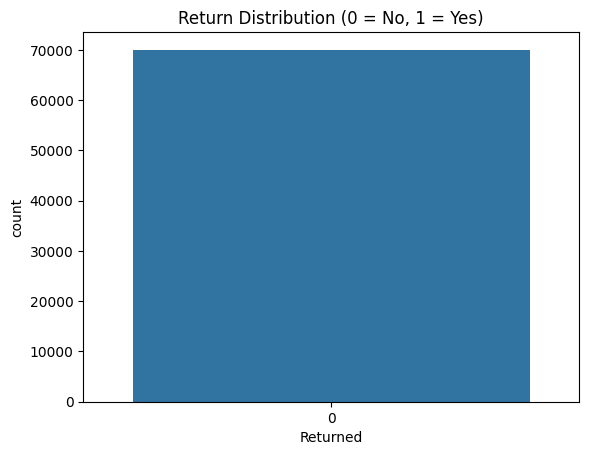

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Returned", data=df)
plt.title("Return Distribution (0 = No, 1 = Yes)")
plt.show()


In [9]:
df = df.drop_duplicates()


In [36]:
df.to_csv("cleaned_order_data.csv", index=False)


In [43]:
df["Returned"] = df["Refunded Item Count"].apply(lambda x: 1 if abs(x) > 0 else 0)


In [44]:
df["Returned"].value_counts()


Returned
0    59268
1    10783
Name: count, dtype: int64

In [50]:
# ✅ Step 1: Feature selection (realistic, no leakage)
selected_features = [
    'Price Reductions',
    'Sales Tax',
    'Purchased Item Count'
]

# ✅ Step 2: Feature matrix and target
X = df[selected_features]
y = df["Returned"]

# ✅ Step 3: Train-test split with stratification
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ✅ Step 4: Train the model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9992862750695882

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     11854
           1       1.00      1.00      1.00      2157

    accuracy                           1.00     14011
   macro avg       1.00      1.00      1.00     14011
weighted avg       1.00      1.00      1.00     14011



In [54]:
# ✅ Predict probability of return for each row
df["Return_Probability"] = model.predict_proba(X)[:, 1]


In [55]:
high_risk_df = df[df["Return_Probability"] > 0.7]
print("High-risk products:", high_risk_df.shape[0])


High-risk products: 10726


In [56]:
high_risk_df.to_csv("high_risk_products.csv", index=False)
